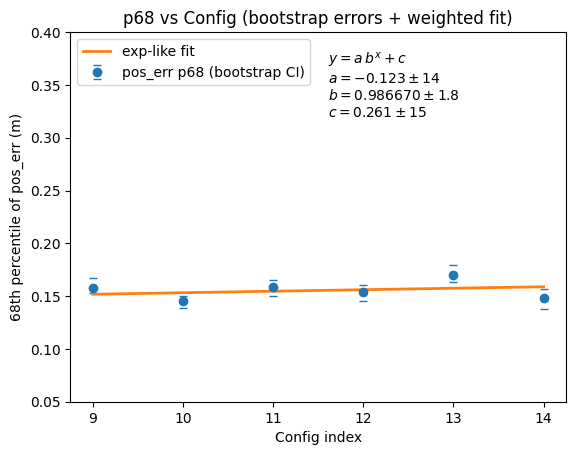

In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

pattern = "/sdf/home/c/cjesus//REFACTORED/LUCiD/s3df_jobs/logs/energy_150k_config_*"

def extract_config_number(path):
    m = re.search(r"config_(\d+)", path)
    return int(m.group(1)) if m else -1

EVENT_RE = re.compile(
    r"Event\s+\d+:\s*"
    r"pos_err=([0-9]*\.?[0-9]+)\s*(cm|m)\s*,\s*"
    r"dir_err=([0-9]*\.?[0-9]+)\s*°\s*,\s*"
    r"t0_err=([0-9]*\.?[0-9]+)\s*,\s*"
    r"E_err=([0-9]*\.?[0-9]+)"
)

def bootstrap_percentile_ci(data, percentile=68, n_bootstrap=50, ci_level=68, rng=None):
    """Bootstrap CI for a given percentile."""
    data = np.asarray(data)
    n = data.size
    if n == 0:
        return None
    if rng is None:
        rng = np.random.default_rng()

    boots = np.empty(n_bootstrap, dtype=float)
    for i in range(n_bootstrap):
        sample = rng.choice(data, size=n, replace=True)
        boots[i] = np.percentile(sample, percentile)

    alpha = (100 - ci_level) / 2
    ci_lower = np.percentile(boots, alpha)
    ci_upper = np.percentile(boots, 100 - alpha)
    est = np.percentile(data, percentile)

    return {
        "estimate": float(est),
        "ci_lower": float(ci_lower),
        "ci_upper": float(ci_upper),
        "std_error": float(np.std(boots, ddof=1)),
    }

def exp_like(x, a, b, c):
    """y = a * b^x + c"""
    return a * (b ** x) + c

# ---------------- collect per-config p68 + bootstrap errors ----------------
rng = np.random.default_rng(123)  # for reproducibility; remove/alter if you want

configs = []
p68_pos = []
p68_pos_err_lo = []
p68_pos_err_hi = []

for i, filename in enumerate(sorted(glob.glob(pattern), key=extract_config_number)):
    # if i == 14 or i == 14:
    #     continue

    cfg = extract_config_number(filename)

    with open(filename, "r") as f:
        text = f.read()

    rows = EVENT_RE.findall(text)
    if not rows:
        continue

    pos_err = []
    for pos, unit, d, t0, E in rows:
        pos = float(pos)
        if unit == "cm":
            pos /= 100.0
        pos_err.append(pos)

    pos_err = np.asarray(pos_err)
    if pos_err.size < 5:  # small-sample guard; tune as you like
        continue

    ci = bootstrap_percentile_ci(pos_err, percentile=68, n_bootstrap=2000, ci_level=68, rng=rng)
    if ci is None:
        continue

    y = ci["estimate"]
    ylo = y - ci["ci_lower"]
    yhi = ci["ci_upper"] - y

    configs.append(cfg)
    p68_pos.append(y)
    p68_pos_err_lo.append(ylo)
    p68_pos_err_hi.append(yhi)

configs = np.asarray(configs, dtype=float)
p68_pos = np.asarray(p68_pos, dtype=float)
p68_pos_err_lo = np.asarray(p68_pos_err_lo, dtype=float)
p68_pos_err_hi = np.asarray(p68_pos_err_hi, dtype=float)

# ---------------- fit (weighted) ----------------
# curve_fit takes 1D sigma; use a symmetric approximation (avg of + / -).
sigma = 0.5 * (p68_pos_err_lo + p68_pos_err_hi)
sigma = np.clip(sigma, 1e-12, None)  # avoid zeros

xdata = configs
ydata = p68_pos

# Reasonable starting point
p0 = [ydata.max() - ydata.min(), 0.99, ydata.min()]
bounds = ([-np.inf, 0.0, -np.inf], [np.inf, np.inf, np.inf])  # b >= 0 helps stability

popt, pcov = curve_fit(
    exp_like, xdata, ydata,
    sigma=sigma, absolute_sigma=True,
    p0=p0, bounds=bounds, maxfev=20000
)

# Optional: 1-sigma parameter errors
perr = np.sqrt(np.diag(pcov))

# ---------------- plot ----------------
fig, ax = plt.subplots()

ax.errorbar(
    xdata, ydata,
    yerr=[p68_pos_err_lo, p68_pos_err_hi],  # asymmetric error bars
    fmt="o", lw=0, capsize=3,
    label="pos_err p68 (bootstrap CI)"
)

xfit = np.linspace(xdata.min(), xdata.max(), 300)
yfit = exp_like(xfit, *popt)
ax.plot(xfit, yfit, "-", lw=2, label="exp-like fit")

a, b, c = popt
da, db, dc = perr

ax.text(
    0.52, 0.95,
    (f"$y = a\\,b^x + c$\n"
     f"$a={a:.3g}\\pm{da:.2g}$\n"
     f"$b={b:.6f}\\pm{db:.2g}$\n"
     f"$c={c:.3g}\\pm{dc:.2g}$"),
    transform=ax.transAxes,
    fontsize=10,
    ha="left", va="top"
)

ax.set_xlabel("Config index")
ax.set_ylabel("68th percentile of pos_err (m)")
ax.set_title("p68 vs Config (bootstrap errors + weighted fit)")
ax.set_ylim(0.05, 0.4)
ax.legend()

plt.show()

In [2]:
import pickle
import sys
sys.path.append('..')

import jax
import jax.numpy as jnp
import numpy as np

# Import matplotlib FIRST, before pyplot
import matplotlib
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 12

# NOW import pyplot - it will use the settings above
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
import torch

from tools.geometry import generate_detector

In [3]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def extract_histories(all_event_results):
    """
    Extract convergence histories for all events.
    
    Returns:
        Dictionary with arrays for each metric, shape (n_events, n_iterations)
    """
    keys = [
        'position_errors',
        'direction_errors',
        't0_errors',
        'energy_errors',
        'combined_losses',
        'vertex_losses',
        'counts_losses',
        'energy_losses'
    ]
    
    # Collect lists via comprehension (faster than nested loops)
    histories = {
        key: [event['optimization_results']['history'][key]
              for event in all_event_results]
        for key in keys
    }
    
    # Convert once
    return {key: np.asarray(value) for key, value in histories.items()}


def compute_statistics(data_array):
    """
    Compute mean, median, 68th percentile, and 90th percentile.
    
    Args:
        data_array: numpy array of shape (n_events, n_iterations)
    
    Returns:
        Dictionary with statistical measures
    """
    return {
        'mean': np.mean(data_array, axis=0),
        'median': np.median(data_array, axis=0),
        'percentile_68': np.percentile(data_array, 68, axis=0),
        'percentile_90': np.percentile(data_array, 90, axis=0)
    }


def bootstrap_percentile_ci(data, percentile=95, n_bootstrap=1000, ci_level=68):
    """
    Compute bootstrap confidence intervals for a given percentile.
    """
    bootstrap_estimates = []
    n = len(data)
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        bootstrap_estimates.append(np.percentile(bootstrap_sample, percentile))
    bootstrap_estimates = np.array(bootstrap_estimates)
    alpha = (100 - ci_level) / 2
    ci_lower = np.percentile(bootstrap_estimates, alpha)
    ci_upper = np.percentile(bootstrap_estimates, 100 - alpha)
    return {
        "estimate": np.percentile(data, percentile),
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "std_error": np.std(bootstrap_estimates),
    }


def exp_like(x, a, b, c):
    """Exponential-like fit function: y = a * b^x + c"""
    return a * (b ** x) + c


def constant(x, q):
    """Constant fit function: y = q"""
    return np.full_like(x, q)


def compute_momentum_errors(energy_errors, true_energy, m_mu=105.658):
    """
    Convert energy errors to momentum errors (%).
    
    Args:
        energy_errors: Array of energy errors
        true_energy: True particle energy (MeV or GeV, must match m_mu units)
        m_mu: Muon mass (default 105.658 MeV, adjust if using GeV)
    
    Returns:
        Momentum errors as percentage
    """
    E_total = true_energy + m_mu
    p_mu = np.sqrt(E_total**2 - m_mu**2)
    conversion_factor = E_total / p_mu
    momentum_errors_percent = (conversion_factor * (energy_errors / E_total)) * 100
    return momentum_errors_percent

# ============================================================
# DATA LOADING AND PROCESSING FUNCTIONS
# ============================================================

def load_and_process_results(results_files, variable_extractor, muon_mass=105.658):
    """
    Load and process results from multiple pickle files.
    
    Args:
        results_files: List of paths to pickle files
        variable_extractor: Function that extracts the x-variable from results_summary
        muon_mass: Muon mass in MeV or GeV (must match energy units)
    
    Returns:
        tuple: (x_values, histories_list, stats_list, results_summaries)
    """
    x_values = []
    histories_list = []
    stats_list = []
    results_summaries = []
    
    for results_file in results_files:
        # Load results
        with open(results_file, 'rb') as f:
            results_summary = pickle.load(f)
            results_summaries.append(results_summary)
        
        print(f"Loaded: {results_file}")
        
        # Extract x-variable value
        x_value = variable_extractor(results_summary)
        x_values.append(x_value)
        print(f"  X-variable value: {x_value}")
        
        # Extract histories
        all_event_results = results_summary['all_event_results']
        histories = extract_histories(all_event_results)
        
        # Compute statistics for all metrics
        stats = {key: compute_statistics(histories[key]) for key in histories}
        
        # Convert energy errors to momentum errors
        true_energy = x_value if 'energy' in results_file else results_summary['config'].get('true_energy', 1050.0)
        momentum_errors_percent = compute_momentum_errors(histories['energy_errors'], true_energy, muon_mass)
        histories['momentum_errors_percent'] = momentum_errors_percent
        stats['momentum_errors_percent'] = compute_statistics(momentum_errors_percent)
        
        histories_list.append(histories)
        stats_list.append(stats)
    
    return x_values, histories_list, stats_list, results_summaries


def extract_timing_metrics(results_summaries):
    """
    Extract timing metrics from results summaries.
    
    Returns:
        tuple: (total_times_mean, total_times_std, adam_times_mean, adam_times_std)
    """
    total_times_mean, total_times_std = [], []
    adam_times_mean, adam_times_std = [], []
    
    for results_summary in results_summaries:
        all_event_results = results_summary["all_event_results"]
        total_t = np.array([ev["total_event_time"] for ev in all_event_results])
        adam_t = np.array([ev.get("adam_optimization_time", np.nan) for ev in all_event_results])
        total_times_mean.append(np.nanmean(total_t))
        total_times_std.append(np.nanstd(total_t))
        adam_times_mean.append(np.nanmean(adam_t))
        adam_times_std.append(np.nanstd(adam_t))
    
    return total_times_mean, total_times_std, adam_times_mean, adam_times_std


def compute_bootstrap_metrics(histories_list, metrics, n_iter=-1, percentile=68, ci_level=68, n_bootstrap=1000, seed=42):
    """
    Compute bootstrap percentile + asymmetric CI for all histories.

    Returns:
        metric_results[metric_key] = {
            "y":      [estimates...],
            "yerr_lo":[estimate - ci_lower ...],
            "yerr_hi":[ci_upper - estimate ...],
            "ci_lower":[ci_lower ...],
            "ci_upper":[ci_upper ...],
        }
    """
    rng = np.random.default_rng(seed)

    metric_results = {
        key: {"y": [], "yerr_lo": [], "yerr_hi": [], "ci_lower": [], "ci_upper": []}
        for key in metrics
    }

    valid_histories = [h for h in histories_list if isinstance(h.get("position_errors", None), np.ndarray)]

    for histories in valid_histories:
        for key, meta in metrics.items():
            data = histories[key][:, n_iter] * meta["scale"]

            # Use your existing bootstrap function, but make it use rng (small edit below),
            # or keep it as-is and accept global np.random. Here I keep it as-is but set seed above.
            boot = bootstrap_percentile_ci(
                data,
                percentile=percentile,
                n_bootstrap=n_bootstrap,
                ci_level=ci_level
            )

            est = boot["estimate"]
            lo = boot["ci_lower"]
            hi = boot["ci_upper"]

            metric_results[key]["y"].append(est)
            metric_results[key]["ci_lower"].append(lo)
            metric_results[key]["ci_upper"].append(hi)
            metric_results[key]["yerr_lo"].append(est - lo)
            metric_results[key]["yerr_hi"].append(hi - est)

    return metric_results

In [4]:
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def plot_metrics_vs_variable(
    x_values,
    metric_results,
    metrics,
    xlabel,
    output_filename,
    x_scale=1.0,
    timing_data=None,
    ylims=None,
    fit_types=None,
    line_color="navy"
):
    """
    Same as your function, but:
      - plots asymmetric bootstrap errors (yerr=[lo, hi])
      - fits using symmetric sigma = 0.5*(lo+hi) as weights
    """
    n_panels = len(metrics) + (1 if timing_data else 0)
    fig, axes = plt.subplots(n_panels, 1, figsize=(6, 2.5 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]
    plt.subplots_adjust(hspace=0.05)

    xdata = np.array(x_values, dtype=float) / float(x_scale)

    # Plot metrics
    for ax, (key, meta) in zip(axes[:len(metrics)], metrics.items()):
        y = np.asarray(metric_results[key]["y"], dtype=float)

        # --- asymmetric error bars ---
        yerr_lo = np.asarray(metric_results[key]["yerr_lo"], dtype=float)
        yerr_hi = np.asarray(metric_results[key]["yerr_hi"], dtype=float)
        yerr_asym = np.vstack([yerr_lo, yerr_hi])  # shape (2, N)

        ax.errorbar(
            xdata, y,
            yerr=yerr_asym,
            fmt="o", capsize=4,
            color=line_color,
            label=meta["label"]
        )

        # --- sigma for curve_fit (must be 1D, symmetric) ---
        sigma = 0.5 * (yerr_lo + yerr_hi)
        sigma = np.clip(sigma, 1e-12, None)  # avoid zeros / inf weights

        # Determine fit type
        fit_type = 'exp' if fit_types is None else fit_types.get(key, 'exp')

        # Fit curve
        try:
            xfit = np.linspace(xdata.min(), xdata.max(), 200)

            if fit_type == 'const':
                popt, _ = curve_fit(
                    constant, xdata, y,
                    sigma=sigma, absolute_sigma=True,
                    p0=[np.nanmean(y)], maxfev=10000
                )
                yfit = constant(xfit, *popt)
                ax.plot(xfit, yfit, "-", color="cornflowerblue", lw=2)
                ax.text(
                    0.55, 0.9,
                    f"$y = {popt[0]:.2f}$",
                    transform=ax.transAxes, fontsize=10, color="cornflowerblue",
                    ha="left", va="top"
                )
            else:
                popt, _ = curve_fit(
                    exp_like, xdata, y,
                    sigma=sigma, absolute_sigma=True,
                    p0=[np.nanmax(y) - np.nanmin(y), 0.99, np.nanmin(y)],
                    maxfev=10000
                )
                yfit = exp_like(xfit, *popt)
                ax.plot(xfit, yfit, "-", color="cornflowerblue", lw=2)

                a, b, c = popt
                ax.text(
                    0.55, 0.9,
                    f"$y = {a:.2f}\\times\\,{b:.3f}^x + {c:.2f}$",
                    transform=ax.transAxes, fontsize=10, color="cornflowerblue",
                    ha="left", va="top"
                )

        except RuntimeError:
            print(f"⚠️ Fit failed for {key}")

        # Set y-axis limits if provided
        if ylims and key in ylims:
            ax.set_ylim(ylims[key])

        ax.set_ylabel(meta["label"])
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Plot timing data if provided (timing errors are already symmetric in your code)
    if timing_data:
        total_mean, total_std, adam_mean, adam_std = timing_data
        ax_time = axes[-1]

        ax_time.errorbar(
            xdata, total_mean, yerr=total_std,
            fmt="o-", capsize=4, color="tab:red", label="Total"
        )
        ax_time.errorbar(
            xdata, adam_mean, yerr=adam_std,
            fmt="s--", capsize=4, color="tab:orange", label="Adam"
        )
        ax_time.set_ylabel("Time per event (s)")
        ax_time.grid(True, alpha=0.3)
        ax_time.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax_time.legend(frameon=False, loc="lower right")
        ax_time.set_ylim(0)
        ax_time.set_xlim(0)

    axes[-1].set_xlabel(xlabel)
    fig.align_ylabels(axes)
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()
    print(f"\nSaved figure to: {output_filename}")

Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_0.pkl
  X-variable value: 5000
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_1.pkl
  X-variable value: 10000
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_2.pkl
  X-variable value: 25000
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_3.pkl
  X-variable value: 50000
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_4.pkl
  X-variable value: 100000
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/config_5.pkl
  X-variable value: 150000


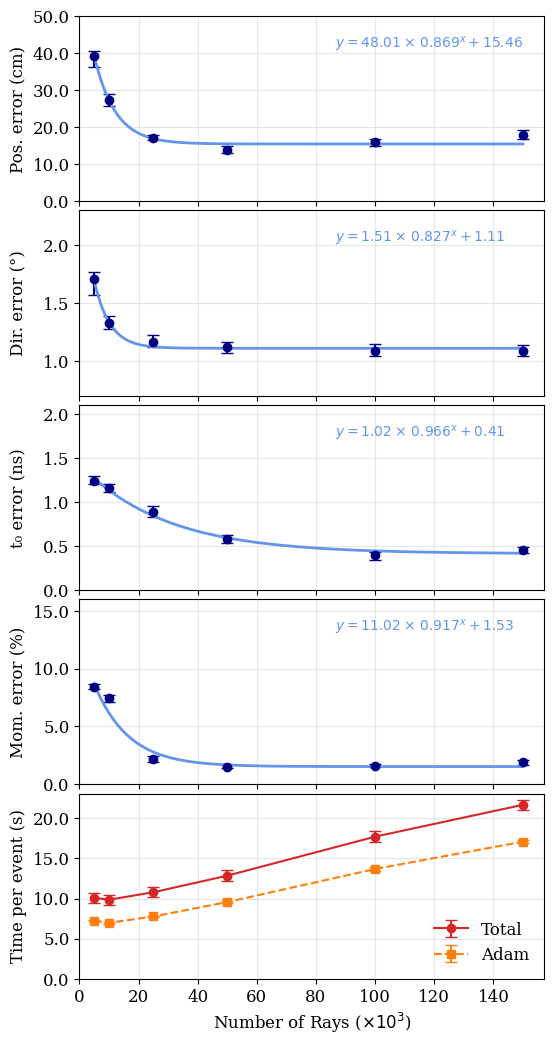


Saved figure to: figures/tracking_performance_vs_nrays.pdf


In [11]:
common_path = '/sdf/data/neutrino/cjesus/fixed_LUCiD/nrays/'
results_files_nrays = [
    common_path + f'config_{i}.pkl' for i in range(0,6)
]

nphot_extractor = lambda rs: rs['config']['nphot']

# Load and process data
x_nrays, hist_nrays, stats_nrays, summaries_nrays = load_and_process_results(
    results_files_nrays, nphot_extractor, muon_mass=0.105658  # GeV
)

timing_nrays = extract_timing_metrics(summaries_nrays)


# Define metrics
metrics = {
    "position_errors": {"label": "Pos. error (cm)", "scale": 100},
    "direction_errors": {"label": "Dir. error (°)", "scale": 1},
    "t0_errors": {"label": "t₀ error (ns)", "scale": 1},
    "momentum_errors_percent": {"label": "Mom. error (%)", "scale": 1},
}

# Compute bootstrap metrics
metric_results_nrays = compute_bootstrap_metrics(hist_nrays, metrics, ci_level=90)

# Plot
plot_metrics_vs_variable(
    x_nrays,
    metric_results_nrays,
    metrics,
    xlabel="Number of Rays ($\\times10^3$)",
    output_filename='figures/tracking_performance_vs_nrays.pdf',
    x_scale=1000.0,
    timing_data=timing_nrays,
    ylims={
        "position_errors": (0, 50),
        "direction_errors": (0.7, 2.3),
        "t0_errors": (0, 2.1),
        "momentum_errors_percent": (0, 16)
    }
)

In [ ]:
common_path = '/sdf/data/neutrino/cjesus/fixed_LUCiD/energy_50k/'
results_files_energy = [
    common_path + f'config_{i}.pkl' for i in  [0,3,6]
]

common_path = '/sdf/data/neutrino/cjesus/fixed_LUCiD/energy_150k_test/'
for i in  [9, 12, 14]:
    results_files_energy.append(common_path + f'config_{i}.pkl')

# Extract energy as x-variable
def energy_extractor(rs):
    all_event_results = rs['all_event_results']
    true_energies = np.array([e['event_data']['true_energy'] for e in all_event_results])
    return int(np.unique(true_energies)[0])

# Load and process data
x_energy, hist_energy, stats_energy, summaries_energy = load_and_process_results(
    results_files_energy, energy_extractor, muon_mass=105.658  # MeV
)

# Define metrics
metrics = {
    "position_errors": {"label": "Pos. error (cm)", "scale": 100},
    "direction_errors": {"label": "Dir. error (°)", "scale": 1},
    "t0_errors": {"label": "t₀ error (ns)", "scale": 1},
    "momentum_errors_percent": {"label": "Mom. error (%)", "scale": 1},
}


# Compute bootstrap metrics
metric_results_energy = compute_bootstrap_metrics(hist_energy, metrics, ci_level=68)

# Plot with constant fit for momentum
plot_metrics_vs_variable(
    x_energy,
    metric_results_energy,
    metrics,
    xlabel="Energy (MeV)",
    output_filename='figures/tracking_performance_vs_energy.pdf',
    x_scale=1.0,
    fit_types={
        "position_errors": "exp",
        "direction_errors": "exp",
        "t0_errors": "const",
        "momentum_errors_percent": "const"
    },
    ylims={
        "position_errors": (10, 35),
        "direction_errors": (0., 2.9),
        "t0_errors": (0, 1.6),
        "momentum_errors_percent": (0, 4.4)
    }
)

Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/energy_50k/config_0.pkl
  X-variable value: 400


Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_0.pkl
  X-variable value: 1886
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_1.pkl
  X-variable value: 3962
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_2.pkl
  X-variable value: 5906
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_3.pkl
  X-variable value: 7940
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_4.pkl
  X-variable value: 9853
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_5.pkl
  X-variable value: 11766
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_6.pkl
  X-variable value: 13734
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_7.pkl
  X-variable value: 15734
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_8.pkl
  X-variable value: 17806
Loaded: /sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/config_9.pkl
  X-variable value: 19939


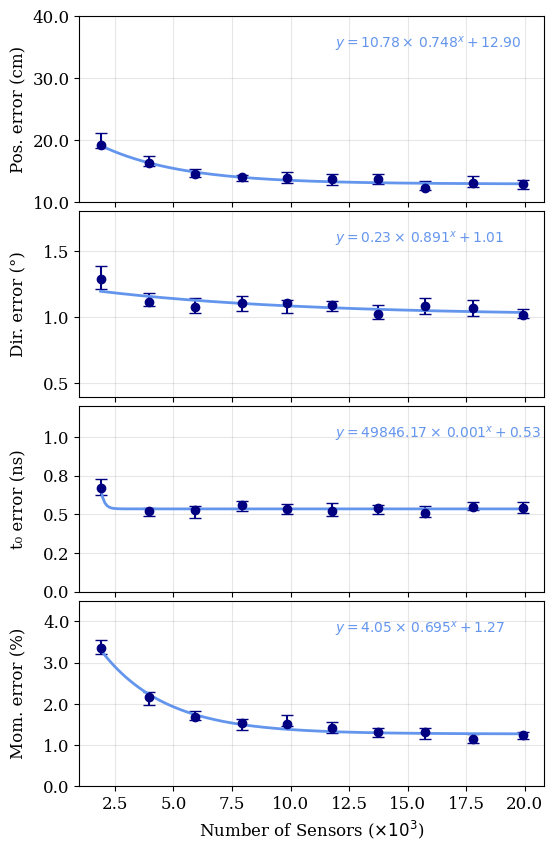


Saved figure to: figures/detector_perf_vs_num_sensors.pdf


In [23]:
# Define file paths and variable extractor
common_path = '/sdf/data/neutrino/cjesus/fixed_LUCiD/geom_50k/'

results_files_sensors = [
    common_path + f'config_{i}.pkl' 
    for i in range(0, 10)
]

# Extract number of sensors as x-variable
def sensors_extractor(rs):
    detector_config_filename = rs['config']['detector_file']
    detector = generate_detector(detector_config_filename)
    return len(detector.all_points)

# Load and process data
x_sensors, hist_sensors, stats_sensors, summaries_sensors = load_and_process_results(
    results_files_sensors, sensors_extractor, muon_mass=105.658  # MeV
)

# Compute bootstrap metrics
metric_results_sensors = compute_bootstrap_metrics(hist_sensors, metrics, ci_level=68)

# Plot (no timing panel for this analysis)
plot_metrics_vs_variable(
    x_sensors,
    metric_results_sensors,
    metrics,
    xlabel="Number of Sensors ($\\times10^3$)",
    output_filename='figures/detector_perf_vs_num_sensors.pdf',
    x_scale=1000.0,
    ylims={
        "position_errors": (10, 40),
        "direction_errors": (0.4, 1.8),
        "t0_errors": (0, 1.2),
        "momentum_errors_percent": (0, 4.5)
    }
)